In [8]:
# Cell 0: Install and Setup Weights & Biases
!pip install wandb -q
import wandb

# This will prompt you to click a link and paste your API key
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 yes


wandb: WARNING Invalid choice
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

...

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: fiamregina (ELTE_dl_competition_team) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [2]:
# Cell 1: Setup and Data Loaders
import sys
import os
import json
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam
from google.colab import drive

# Mount Drive and load config
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
PROJECT_ROOT = '/content/drive/MyDrive/Advanced Machine Learning Project'
sys.path.append(PROJECT_ROOT)

with open(os.path.join(PROJECT_ROOT, 'config.json'), 'r') as f:
    config = json.load(f)


In [4]:
# Load Tensors
tensor_path = os.path.join(PROJECT_ROOT, 'data', 'processed_tensors.pt')
saved_data = torch.load(tensor_path)
X_tensor, y_tensor = saved_data['X'], saved_data['y']

# Chronological Split (80% Train, 20% Validation)
split_idx = int(len(X_tensor) * 0.8)
X_train, y_train = X_tensor[:split_idx], y_tensor[:split_idx]
X_val, y_val = X_tensor[split_idx:], y_tensor[split_idx:]

batch_size = config['training']['batch_size']
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=False)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

print(f"Train samples: {len(X_train)} | Val samples: {len(X_val)}")

Train samples: 1785 | Val samples: 447


In [10]:
# Cell 2: Model and Loss Function Setup
from src.model import SP500Transformer
from torch.optim import Adam
import torch.nn as nn
import torch

# Initialize Model dynamically based on data shape
num_features = X_train.shape[2]
model = SP500Transformer(
    num_features=num_features,
    d_model=config['model']['d_model'],
    nhead=config['model']['nhead'],
    num_layers=config['model']['num_layers'],
    seq_len=config['data']['sequence_length'],
    dropout=config['model']['dropout']
)

# Loss and Optimizer
# FIX: Removed pos_weight to prevent forcing the model into a corner
criterion = nn.BCEWithLogitsLoss()
optimizer = Adam(model.parameters(), lr=config['training']['learning_rate'], weight_decay=1e-5)

# Use GPU if available in Colab
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
criterion.to(device)

print(f"Model built and moved to: {device}")

Model built and moved to: cpu


In [11]:
# Cell 3: Execute Training with W&B Logging
import wandb
import numpy as np
import torch

# Initialize W&B run
run = wandb.init(
    project="sp500-transformer",
    name=f"run_seq{config['data']['sequence_length']}_lr{config['training']['learning_rate']}",
    config=config
)

epochs = config['training']['epochs']

print("Starting Training...")
for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    batch_train_loss = []

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()
        batch_train_loss.append(loss.item())

    avg_train_loss = np.mean(batch_train_loss)

    # --- VALIDATION PHASE ---
    model.eval()
    batch_val_loss = []
    correct_preds = 0
    total_preds = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            batch_val_loss.append(loss.item())

            # Convert logits to 0 or 1
            predictions = (torch.sigmoid(logits) > 0.5).float()
            correct_preds += (predictions == y_batch).sum().item()
            total_preds += y_batch.size(0)

    avg_val_loss = np.mean(batch_val_loss)
    val_accuracy = correct_preds / total_preds

    # --- LOGGING TO WANDB ---
    wandb.log({
        "epoch": epoch + 1,
        "Train Loss": avg_train_loss,
        "Val Loss": avg_val_loss,
        "Val Accuracy": val_accuracy
    })

    # Still print to console so you can monitor it without leaving Colab
    if (epoch + 1) % 2 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.4f}")

# Finish the W&B run
wandb.finish()
print("Training Complete! View your dashboard via the W&B link above.")

Starting Training...
Epoch 01/20 | Train Loss: 0.6964 | Val Loss: 0.7015 | Val Acc: 0.5280
Epoch 02/20 | Train Loss: 0.6925 | Val Loss: 0.6927 | Val Acc: 0.5280
Epoch 04/20 | Train Loss: 0.6901 | Val Loss: 0.6928 | Val Acc: 0.5280
Epoch 06/20 | Train Loss: 0.6889 | Val Loss: 0.6923 | Val Acc: 0.5280
Epoch 08/20 | Train Loss: 0.6886 | Val Loss: 0.6926 | Val Acc: 0.5280
Epoch 10/20 | Train Loss: 0.6882 | Val Loss: 0.6923 | Val Acc: 0.5280
Epoch 12/20 | Train Loss: 0.6885 | Val Loss: 0.6922 | Val Acc: 0.5280
Epoch 14/20 | Train Loss: 0.6887 | Val Loss: 0.6922 | Val Acc: 0.5280
Epoch 16/20 | Train Loss: 0.6887 | Val Loss: 0.6924 | Val Acc: 0.5280
Epoch 18/20 | Train Loss: 0.6892 | Val Loss: 0.6919 | Val Acc: 0.5280
Epoch 20/20 | Train Loss: 0.6885 | Val Loss: 0.6925 | Val Acc: 0.5280


Train Loss,█▅▃▃▂▂▁▁▂▁▂▁▂▁▁▁▂▂▁▁
Val Accuracy,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Val Loss,█▂▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
Train Loss,0.68852
Val Accuracy,0.52796
Val Loss,0.6925
epoch,20


Training Complete! View your dashboard via the W&B link above.


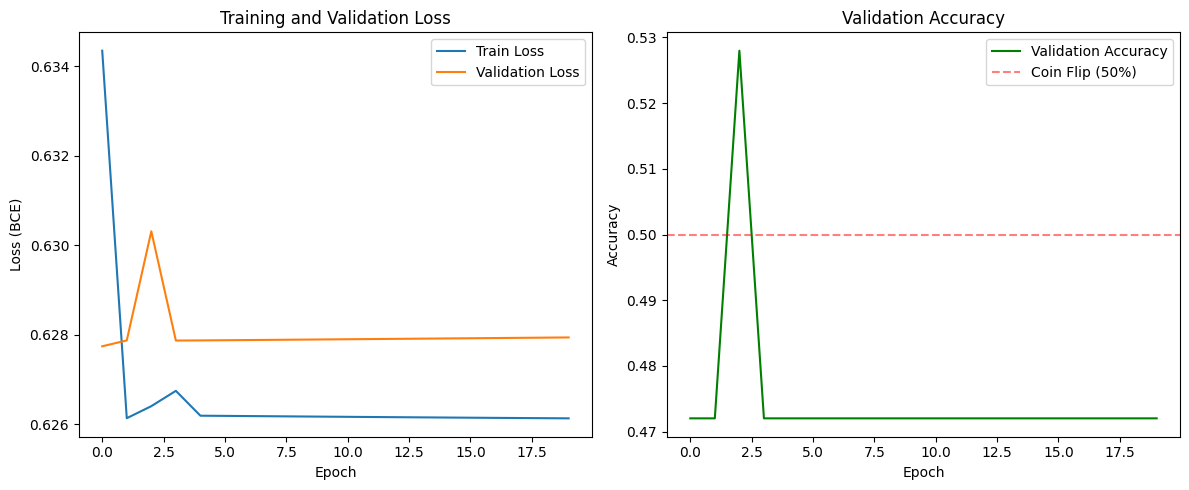

In [7]:
# Cell 4: Plot Learning Curves
plt.figure(figsize=(12, 5))

# Plot Losses
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (BCE)')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy', color='green')
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Coin Flip (50%)')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()